# GSE202642 HCC tumor cell clustering and RNA annotation
7 HCC tumor samples only. This executed companion checks the saved clustering, marker evidence and annotations and displays figures. `cluster.py` reproduces full-matrix QC, normalization, batch-aware HVGs, PCA, unintegrated UMAP, Harmony, Leiden and marker discovery. `annotate.py` and `plot_annotation.py` reproduce labels and figures. UMAP positions do not establish biological identities; labels use marker RNA evidence.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd
from scipy import sparse
from IPython.display import display, Image
R=Path.cwd()
a=pd.read_csv(R/'cell_annotations.csv.gz',index_col=0,dtype={'cluster':str})
u=pd.read_csv(R/'UMAP_coordinates.csv.gz',index_col=0)
defs=pd.read_csv(R/'cluster_annotations.csv',dtype={'cluster':str})
summary=json.loads((R/'clustering_summary.json').read_text())
assert len(a)==56719 and a.index.is_unique and a.index.equals(u.index)
assert a.sample_name.nunique()==7 and a.tissue.eq('HCC_tumor').all()
assert a.cell_type_EN.notna().all() and len(defs)==a.cluster.nunique()
assert np.isfinite(u.to_numpy()).all()
assert a.n_genes.ge(500).all() and a.pct_mt.lt(20).all()
display(a.groupby('cell_type_EN').size().rename('cells').sort_values(ascending=False).to_frame())
print('Leiden clusters:',a.cluster.nunique(),'seed agreement ARI:',summary['seed_stability_ARI'])

,cells
cell_type_EN,
T cells,16123
Macrophages,11536
Hepatocyte-like cells,6773
Endothelial cells,5582
NK cells,5117
CD1C DC-like myeloid,3822
Mural cells,2035
Monocytes,1925
Cycling mixed lineage,1386


Leiden clusters: 21 seed agreement ARI: 0.8744864897483309


In [2]:
raw=sparse.load_npz(R/'marker_raw_counts.npz')
genes=pd.read_csv(R/'marker_genes.csv').gene.tolist()
assert raw.shape==(len(a),len(genes))
source=pd.read_csv(R/'source_inputs/all_cell_metadata_before_QC.csv.gz',index_col=0).loc[a.index]
assert np.array_equal(raw[:,genes.index('PGAM5')].toarray().ravel(),source.PGAM5_counts)
assert np.array_equal(a.total_counts,source.total_counts)
z=raw.astype(float).multiply(10000/a.total_counts.to_numpy()[:,None]).tocsr();z.data=np.log1p(z.data)
e=pd.read_csv(R/'cluster_marker_evidence.csv',dtype={'cluster':str})
for c in a.cluster.unique():
    ix=np.flatnonzero(a.cluster.eq(c))
    group=e[e.cluster.eq(c)].set_index('gene').loc[genes]
    assert np.allclose(np.asarray((raw[ix]>0).mean(0)).ravel(),group.fraction)
    assert np.allclose(np.asarray(z[ix].mean(0)).ravel(),group.mean_log1p_CP10k,atol=2e-5)
print('Independent marker fractions and normalized means match all cluster evidence tables.')
display(defs[['cluster','cell_type_EN','cell_type_CN','annotation_confidence','rationale']])

Independent marker fractions and normalized means match all cluster evidence tables.


,cluster,cell_type_EN,cell_type_CN,annotation_confidence,rationale
0,0,Macrophages,巨噬细胞,supported_RNA,C1Q genes almost universal; CSF1R 85%; FOLR2/C...
1,1,CD1C DC-like myeloid,CD1C树突样髓系细胞,qualified_RNA,CD1C/FCER1A/CLEC10A/FLT3 enriched; concurrent ...
2,2,Macrophages,巨噬细胞,supported_RNA,C1QA 90%; C1Q/APOC1/HLA-II dominant; CSF1R det...
3,3,Monocytes,单核细胞,supported_RNA,FCN1 82%; FCN1/VCAN/CD300E/S100A8/S100A9 enric...
4,4,T cells,T细胞,supported_RNA,"CD3/TRAC-positive; FOXP3 44%, CTLA4 58%, IL2RA..."
5,5,T cells,T细胞,supported_RNA,Multiple CD3 genes 64-69%; NKG7 91%; GZMH/CCL5...
6,6,Hepatocyte-like cells,肝细胞样细胞,supported_RNA,Coherent hepatic/epithelial program; AOX1/TSPA...
7,7,Hepatocyte-like cells,肝细胞样细胞,supported_RNA,APOC3/APOA2/FABP1/ALB/ALDOB coherent hepatic p...
8,8,Hepatocyte-like cells,肝细胞样细胞,supported_RNA,CYP3A5/ACSM2B/PCK1/GPAM/ONECUT1 metabolic hepa...
9,9,NK cells,NK细胞,supported_RNA,GNLY 92%; FGFBP2/GNLY/GZMB/KLRD1/PRF1 enriched...


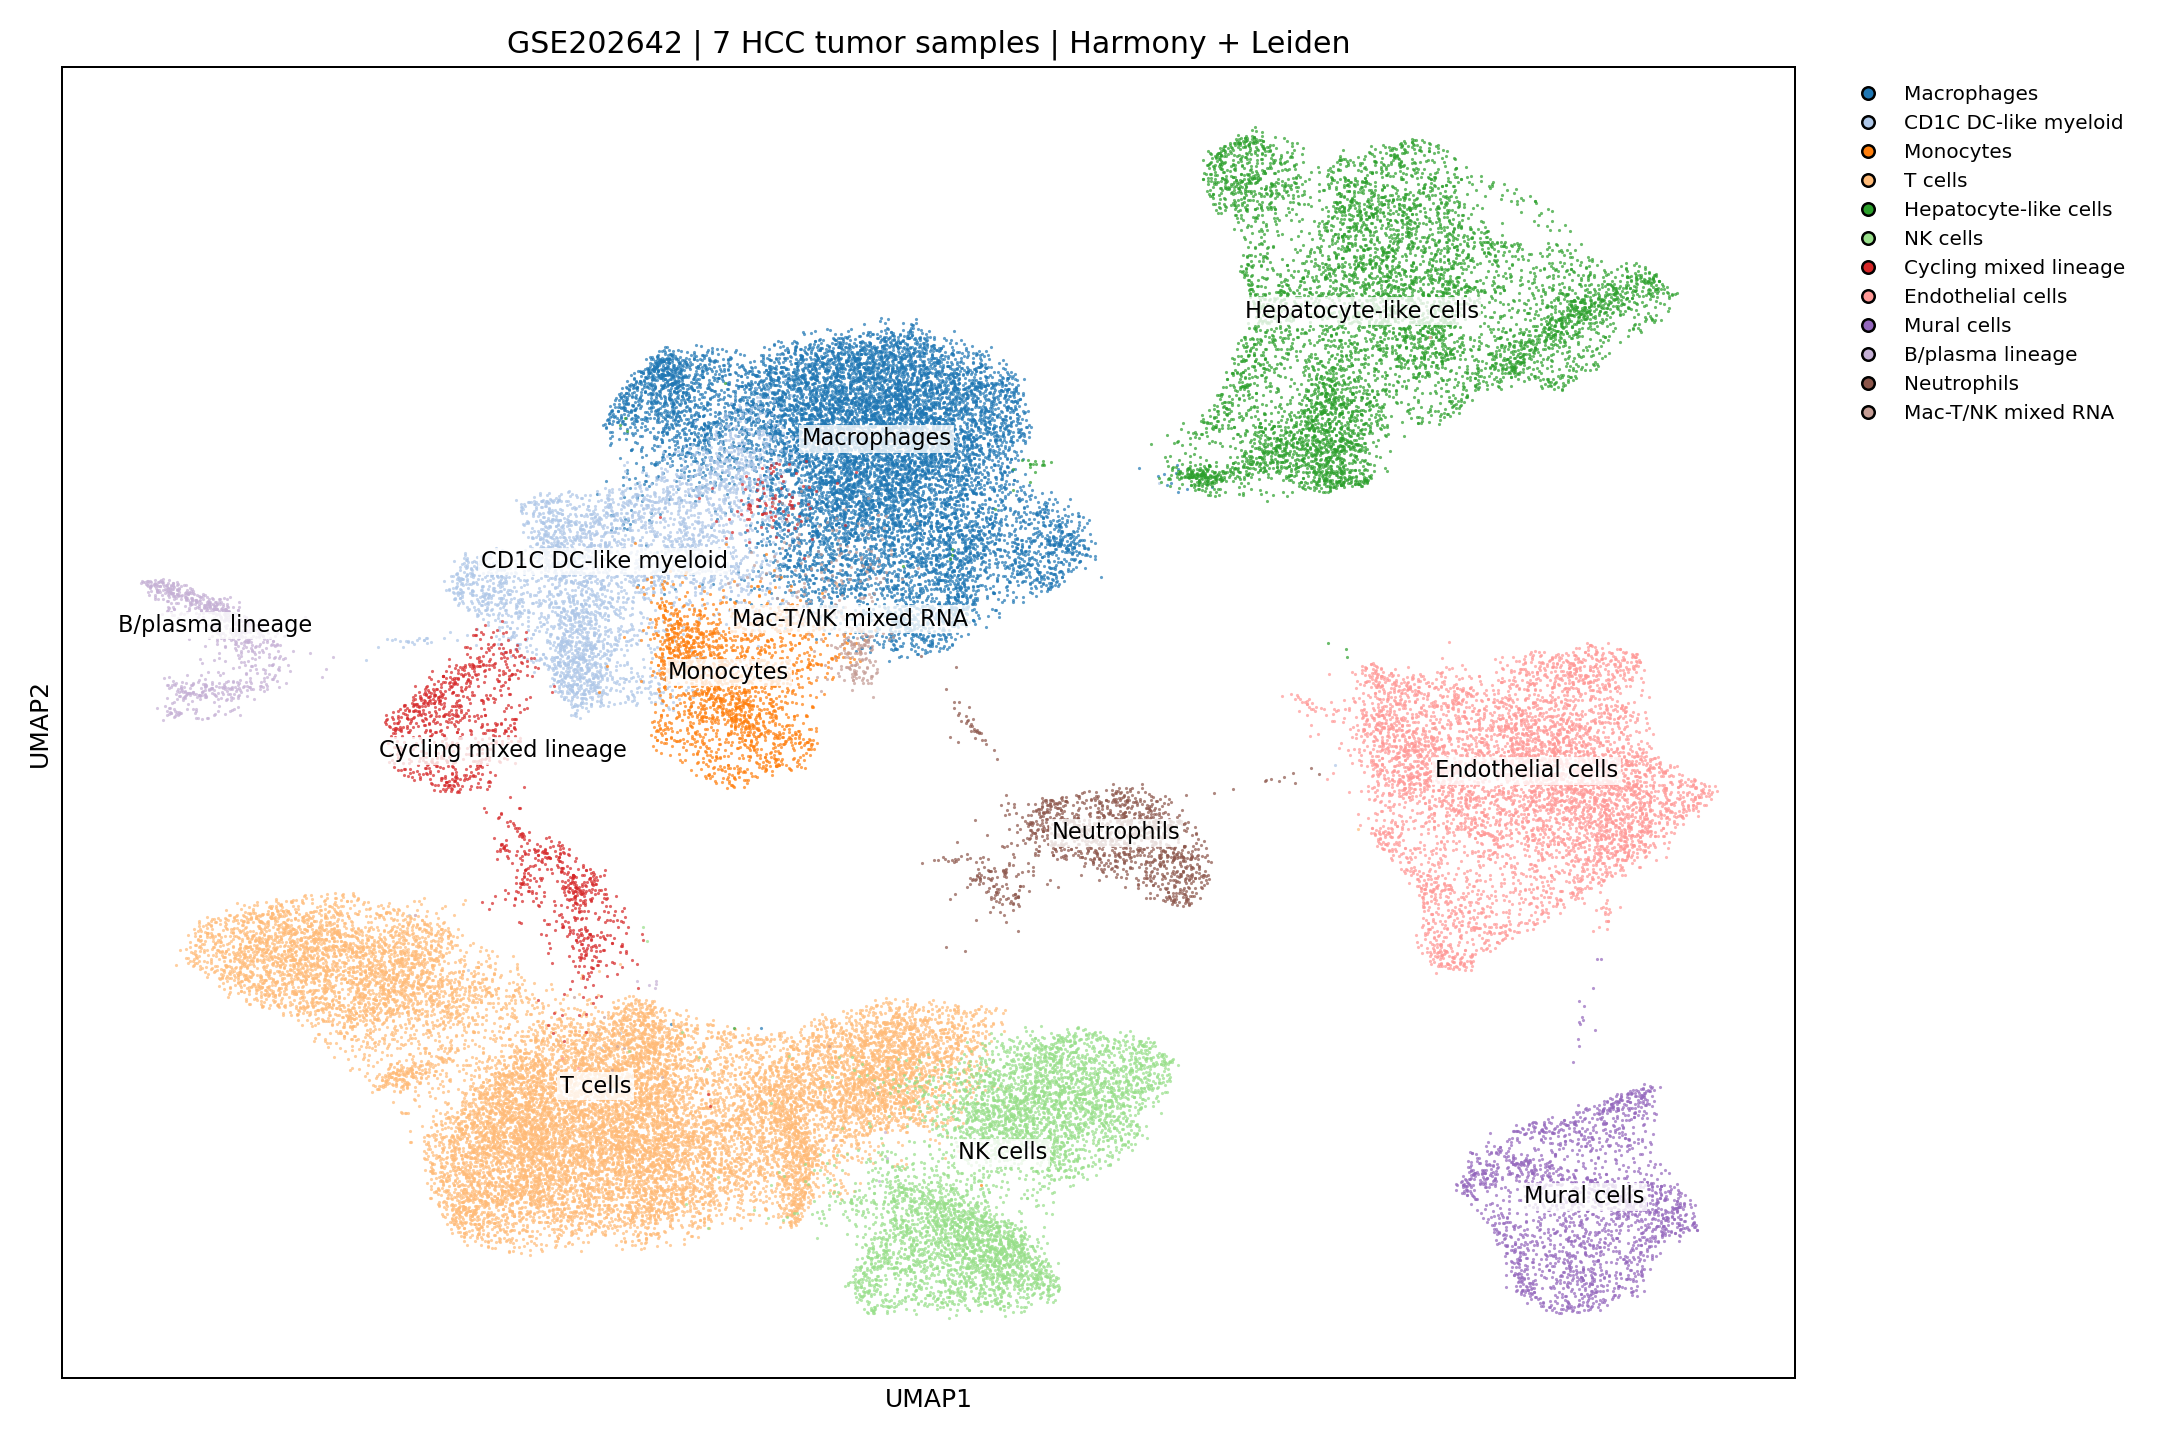

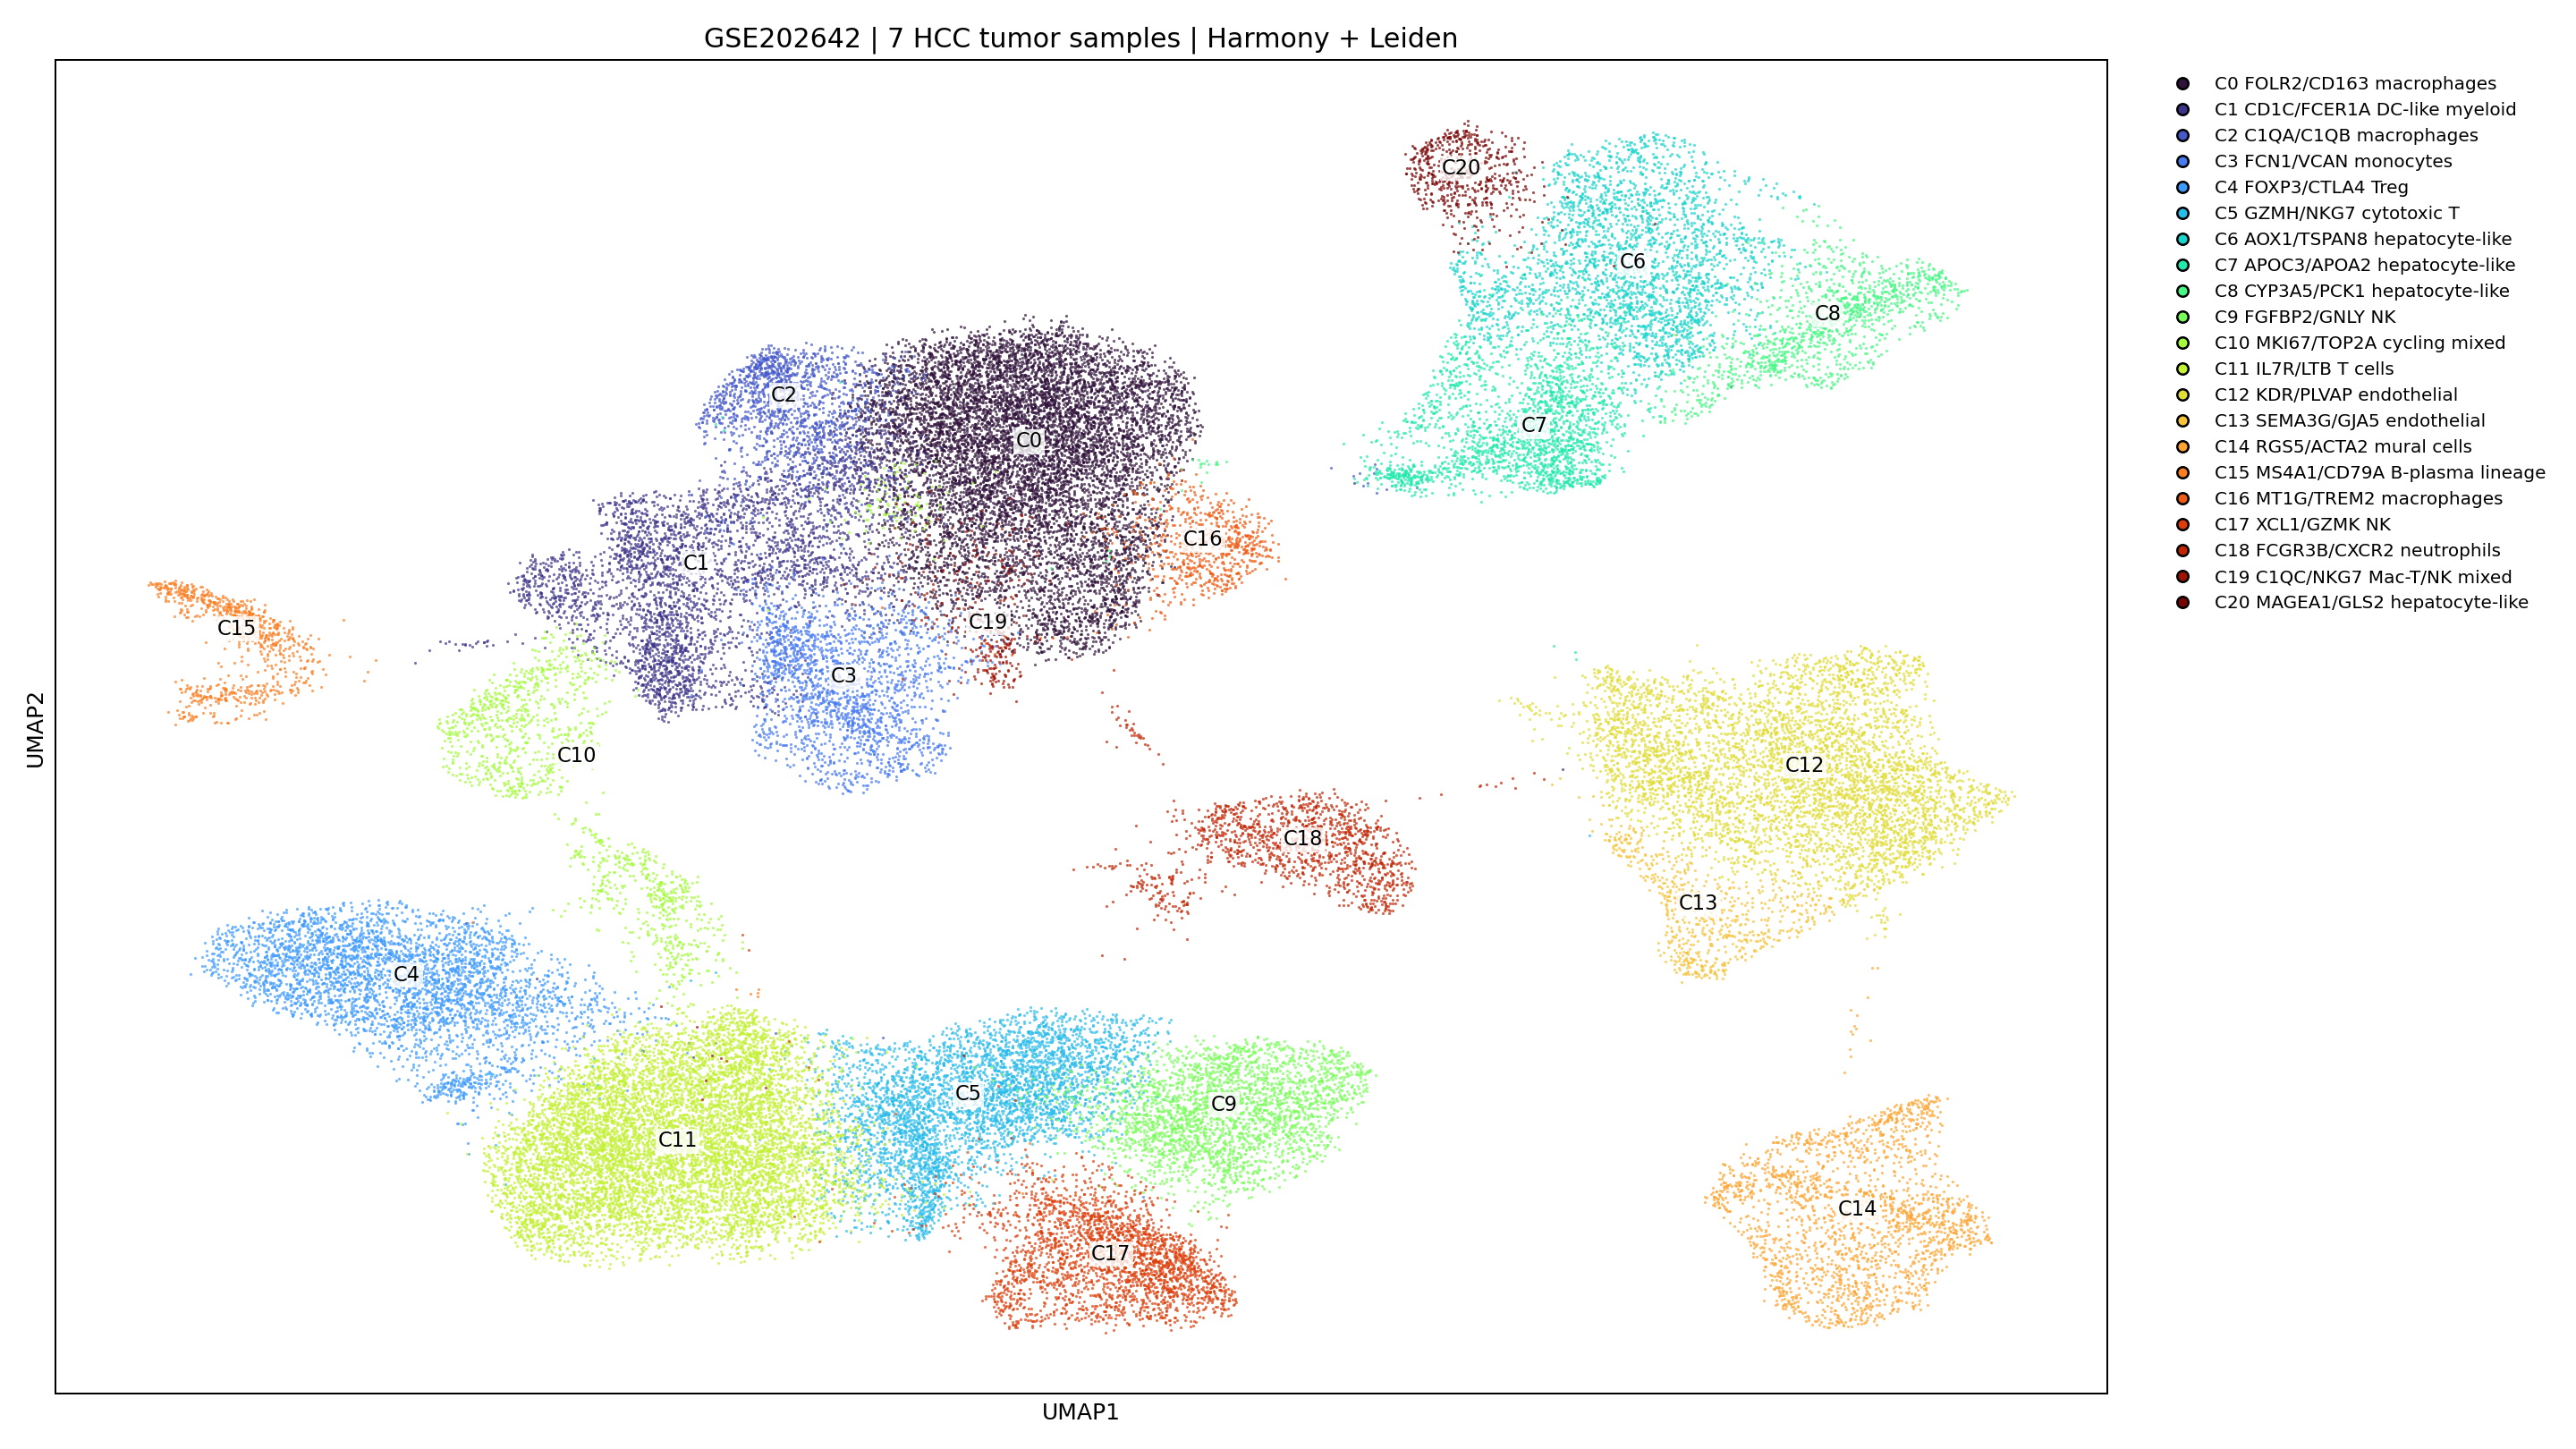

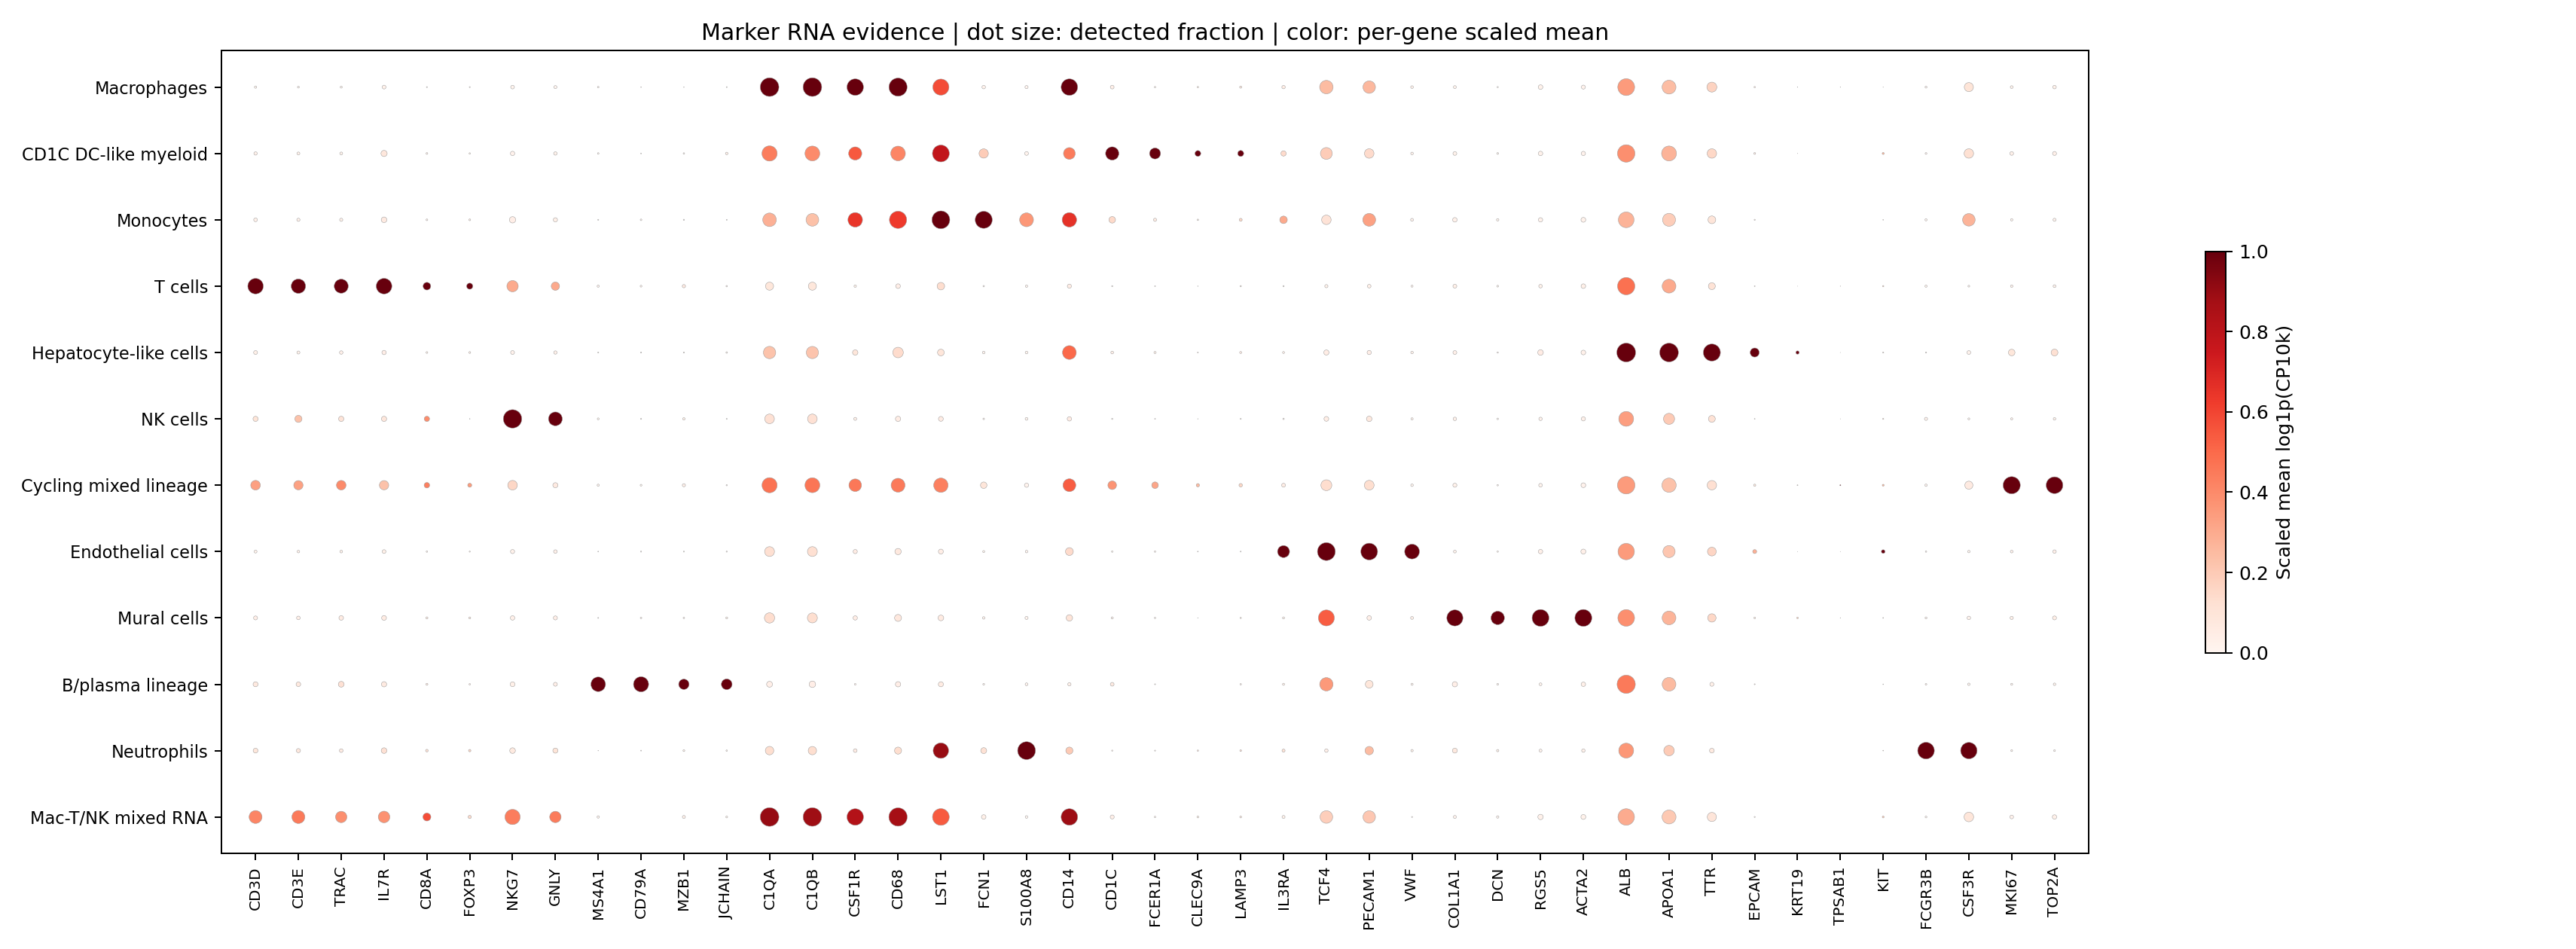

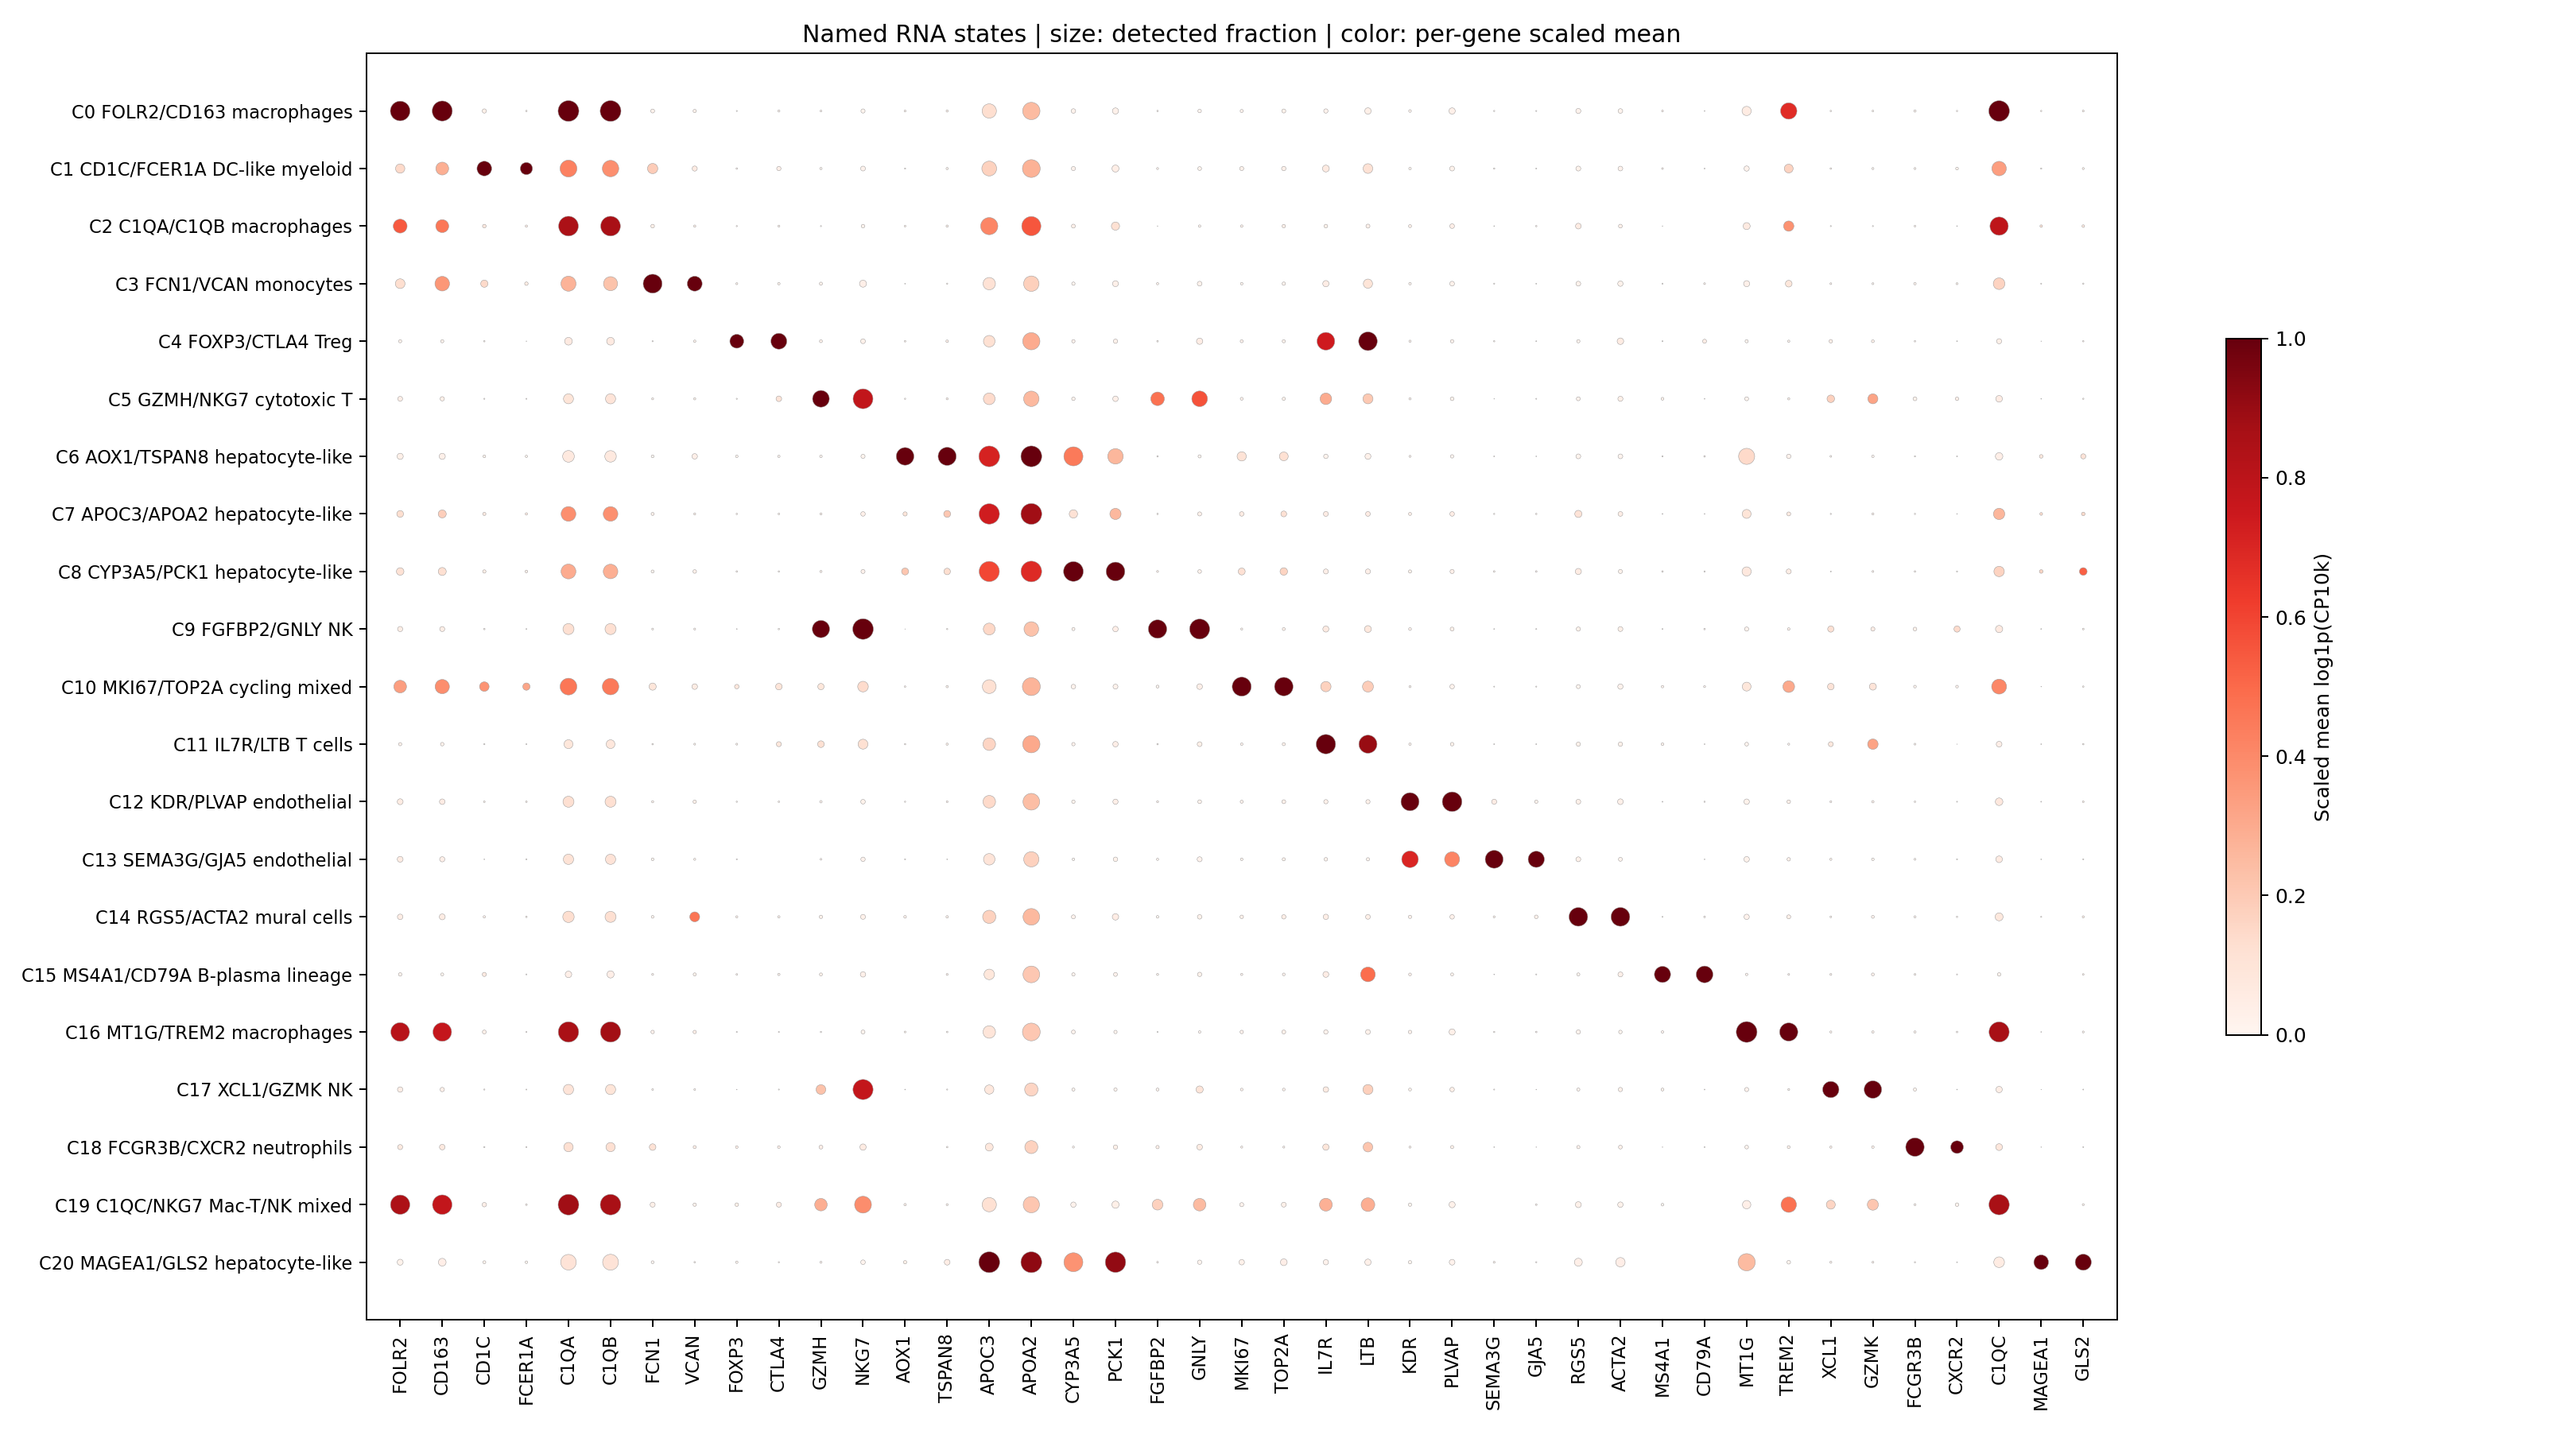

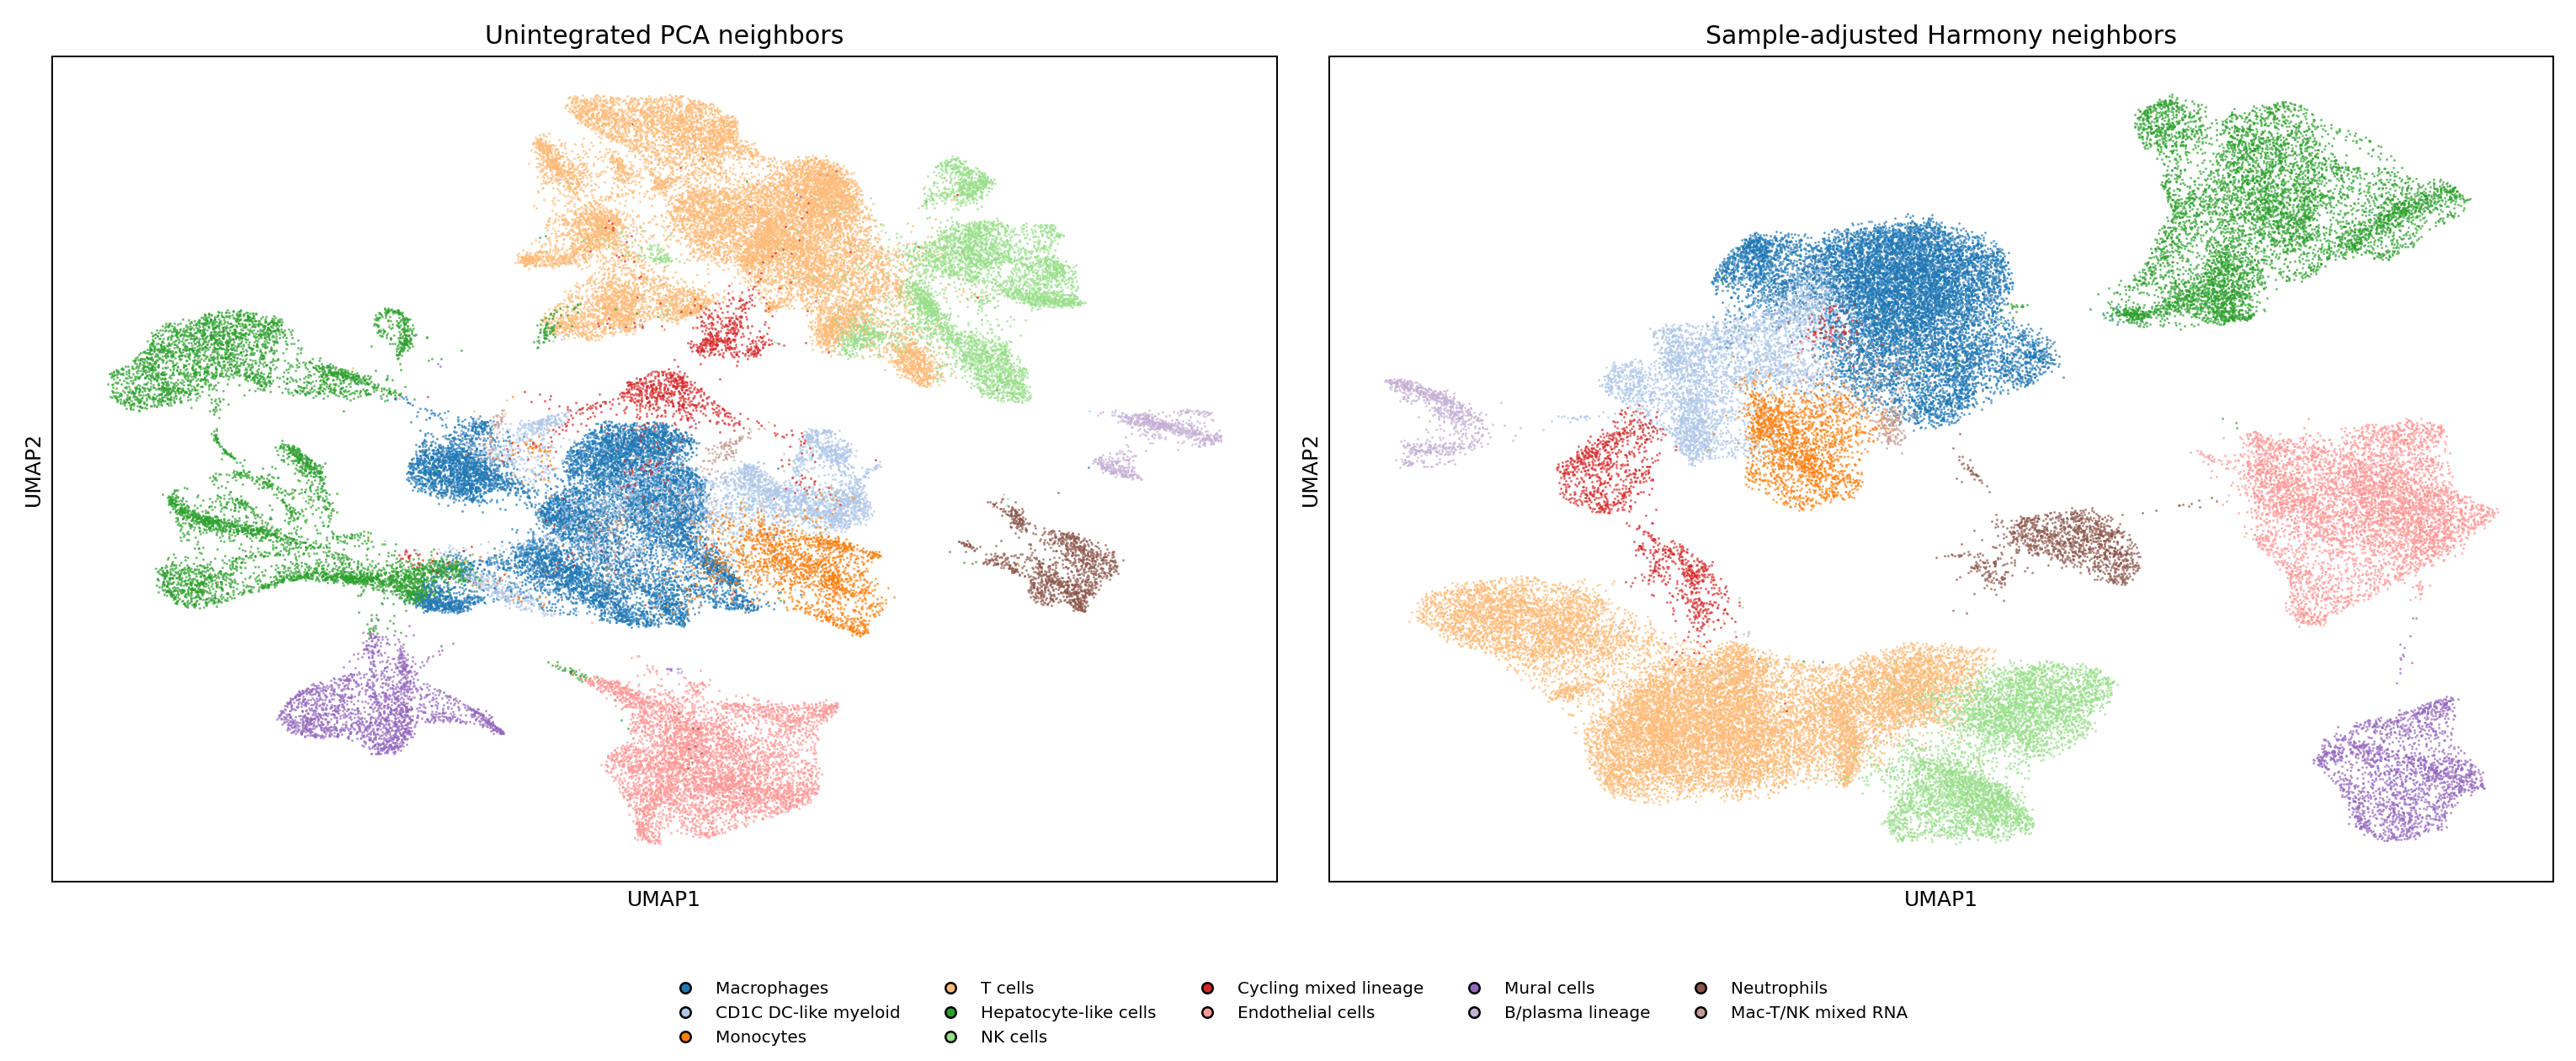

In [3]:
display(Image(filename=str(R/'UMAP_cell_types.png')))
display(Image(filename=str(R/'UMAP_named_clusters.png')))
display(Image(filename=str(R/'celltype_marker_dotplot.png')))
display(Image(filename=str(R/'named_cluster_marker_dotplot.png')))
display(Image(filename=str(R/'UMAP_integration_comparison.png')))

## Limits
RNA-based exploratory annotation, not validated lineage tracing. Hepatocyte-like and epithelial labels do not establish malignancy without copy-number or other supporting data. Mixed/uncertain clusters remain explicit. No formal doublet detection or ambient RNA correction was performed. Harmony may remove some patient biological differences; the unintegrated embedding is retained for comparison. New all-cell cluster IDs are distinct from the previous macrophage-only cluster IDs. The portable h5ad contains marker genes only; full expression matrices stay in the execution workspace.